In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
print("Google Drive mounted and pandas imported.")

Mounted at /content/drive
Google Drive mounted and pandas imported.


**Reasoning**:
Now that Google Drive is mounted and pandas is imported, I will define the dataset path and load the train, valid, and test TSV files into DataFrames, renaming the relevant columns as specified in the subtask.



In [ ]:
dataset_path = '/content/drive/MyDrive/Festiva Moments/Assignment 2/Datasets/'

def load_and_rename_dataset(file_path):
    df = pd.read_csv(file_path, sep='\t', header=None) # LIAR dataset often lacks header and uses tab separator
    # Based on common LIAR dataset structure:
    # Column 0: ID (integer)
    # Column 1: label (e.g., 'half-true', 'true', 'false', 'barely-true', 'pants-on-fire', 'not-applicable')
    # Column 2: statement
    # Other columns are additional metadata.

    # Select statement (original index 2) and label (original index 1)
    df = df.iloc[:, [1, 2]] # Select label (index 1) and statement (index 2)
    df.columns = ['label', 'statement']
    # The '.json' suffix was likely from the ID column being mistakenly assigned to 'label' previously.
    # With correct column assignment, this line might be redundant but harmless if no .json suffixes exist in actual labels.
    df['label'] = df['label'].astype(str).str.replace('.json', '', regex=False)
    return df

train_df = load_and_rename_dataset(dataset_path + 'train.tsv')
valid_df = load_and_rename_dataset(dataset_path + 'valid.tsv')
test_df = load_and_rename_dataset(dataset_path + 'test.tsv')

print("Train DataFrame head:")
print(train_df.head())
print("\nValid DataFrame head:")
print(valid_df.head())
print("\nTest DataFrame head:")
print(test_df.head())

Train DataFrame head:
         label                                          statement
0        false  Says the Annies List political group supports ...
1    half-true  When did the decline of coal start? It started...
2  mostly-true  Hillary Clinton agrees with John McCain "by vo...
3        false  Health care reform legislation is likely to ma...
4    half-true  The economic turnaround started at the end of ...

Valid DataFrame head:
         label                                          statement
0  barely-true  We have less Americans working now than in the...
1   pants-fire  When Obama was sworn into office, he DID NOT u...
2        false  Says Having organizations parading as being so...
3    half-true     Says nearly half of Oregons children are poor.
4    half-true  On attacks by Republicans that various program...

Test DataFrame head:
        label                                          statement
0        true  Building a wall on the U.S.-Mexico border will...
1       fal

In [ ]:
print("\nTrain DataFrame label distribution:")
print(train_df['label'].value_counts())

print("\nValid DataFrame label distribution:")
print(valid_df['label'].value_counts())

print("\nTest DataFrame label distribution:")
print(test_df['label'].value_counts())


Train DataFrame label distribution:
label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64

Valid DataFrame label distribution:
label
false          263
mostly-true    251
half-true      248
barely-true    237
true           169
pants-fire     116
Name: count, dtype: int64

Test DataFrame label distribution:
label
half-true      265
false          249
mostly-true    241
barely-true    212
true           208
pants-fire      92
Name: count, dtype: int64


In [ ]:
import torch
from transformers import AutoTokenizer

# 2. Define a mapping for the categorical string labels to numerical integer IDs.
label_map = {
    'pants-fire': 0,
    'false': 1,
    'barely-true': 2,
    'half-true': 3,
    'mostly-true': 4,
    'true': 5
}

# 3. Apply this mapping to the 'label' column of train_df, valid_df, and test_df
train_df['label_id'] = train_df['label'].map(label_map)
valid_df['label_id'] = valid_df['label'].map(label_map)
test_df['label_id'] = test_df['label'].map(label_map)

# 4. Initialize the AutoTokenizer for bert-base-uncased.
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# 5. Tokenize the 'statement' column for train_df, valid_df, and test_df
def tokenize_data(df, tokenizer):
    return tokenizer(df['statement'].tolist(),
                     padding=True,
                     truncation=True,
                     return_tensors='pt',
                     max_length=128) # Max length chosen as a common practice for BERT

train_encodings = tokenize_data(train_df, tokenizer)
valid_encodings = tokenize_data(valid_df, tokenizer)
test_encodings = tokenize_data(test_df, tokenizer)

# 6. Create TensorDataset for each dataset
train_labels = torch.tensor(train_df['label_id'].values)
valid_labels = torch.tensor(valid_df['label_id'].values)
test_labels = torch.tensor(test_df['label_id'].values)

train_dataset = torch.utils.data.TensorDataset(
    train_encodings['input_ids'],
    train_encodings['attention_mask'],
    train_labels
)
valid_dataset = torch.utils.data.TensorDataset(
    valid_encodings['input_ids'],
    valid_encodings['attention_mask'],
    valid_labels
)
test_dataset = torch.utils.data.TensorDataset(
    test_encodings['input_ids'],
    test_encodings['attention_mask'],
    test_labels
)

print("Tokenization and data formatting complete.")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(valid_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenization and data formatting complete.
Train dataset size: 10240
Validation dataset size: 1284
Test dataset size: 1267


In [ ]:
pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from transformers import BertForSequenceClassification, TrainingArguments, Trainer
import evaluate
import torch.nn as nn

# 1. Create PyTorch DataLoader objects
batch_size = 32 # Using a common batch size for BERT fine-tuning

# Define a custom data collator for TensorDataset
def collate_fn_for_tensor_dataset(batch):
    input_ids = torch.stack([item[0] for item in batch])
    attention_mask = torch.stack([item[1] for item in batch])
    labels = torch.stack([item[2] for item in batch])
    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels
    }

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_for_tensor_dataset)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_for_tensor_dataset)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_for_tensor_dataset)

print(f"Train DataLoader created with {len(train_dataloader)} batches of size {batch_size}.")
print(f"Valid DataLoader created with {len(valid_dataloader)} batches of size {batch_size}.")
print(f"Test DataLoader created with {len(test_dataloader)} batches of size {batch_size}.")

# 2. Initialize BertForSequenceClassification model
num_labels = len(label_map)

# Initialize the model without the 'loss_weights' argument
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

print(f"BertForSequenceClassification model initialized with {num_labels} output labels.")

# Define a custom Trainer to handle weighted loss
class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=0): # Added 'num_items_in_batch'
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Ensure class_weights are on the same device as labels and logits
        if self.class_weights is not None:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(labels.device))
        else:
            loss_fct = nn.CrossEntropyLoss()

        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

print("CustomTrainer defined for weighted loss.")

# 3. Define TrainingArguments
training_args = TrainingArguments(
    output_dir='./results_weighted', # Changed output directory to distinguish from previous training
    eval_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs_weighted', # Changed logging directory
    logging_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    save_strategy='epoch'
)

print("TrainingArguments defined for weighted loss training.")

# 4. Define compute_metrics function (remains the same)
metric = evaluate.load('f1')
accuracy_metric = evaluate.load('accuracy')
precision_metric = evaluate.load('precision')
recall_metric = evaluate.load('recall')

def compute_metrics(p):
    predictions = np.argmax(p.predictions, axis=1)
    labels = p.label_ids

    f1 = metric.compute(predictions=predictions, references=labels, average='weighted')['f1']
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)['accuracy']
    precision = precision_metric.compute(predictions=predictions, references=labels, average='weighted')['precision']
    recall = recall_metric.compute(predictions=predictions, references=labels, average='weighted')['recall']

    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

print("compute_metrics function defined.")

# 5. Initialize CustomTrainer with the new model and class weights
trainer = CustomTrainer( # Use CustomTrainer here
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,  # Use the validation dataset for evaluation during training
    data_collator=collate_fn_for_tensor_dataset, # Pass the custom data collator
    compute_metrics=compute_metrics,
    class_weights=weights # Pass class weights to the CustomTrainer
)

print("Trainer initialized for weighted loss training. Starting retraining...")

# 6. Train the model
trainer.train()

print("Model fine-tuning with weighted loss complete.")


Train DataLoader created with 320 batches of size 32.
Valid DataLoader created with 41 batches of size 32.
Test DataLoader created with 40 batches of size 32.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

BertForSequenceClassification model initialized with 6 output labels.
CustomTrainer defined for weighted loss.
TrainingArguments defined for weighted loss training.
compute_metrics function defined.
Trainer initialized for weighted loss training. Starting retraining...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,1.713878,0.240654,0.210153,0.250824,0.240654
2,1.733651,1.694388,0.236760,0.213273,0.249116,0.236760
3,1.733651,1.708323,0.245327,0.236573,0.259532,0.245327


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Model fine-tuning with weighted loss complete.



Classification Report:
              precision    recall  f1-score   support

  pants-fire       0.36      0.29      0.32        92
       false       0.33      0.33      0.33       249
 barely-true       0.25      0.20      0.22       212
   half-true       0.28      0.25      0.26       265
 mostly-true       0.26      0.41      0.32       241
        true       0.29      0.21      0.25       208

    accuracy                           0.29      1267
   macro avg       0.29      0.28      0.28      1267
weighted avg       0.29      0.29      0.28      1267



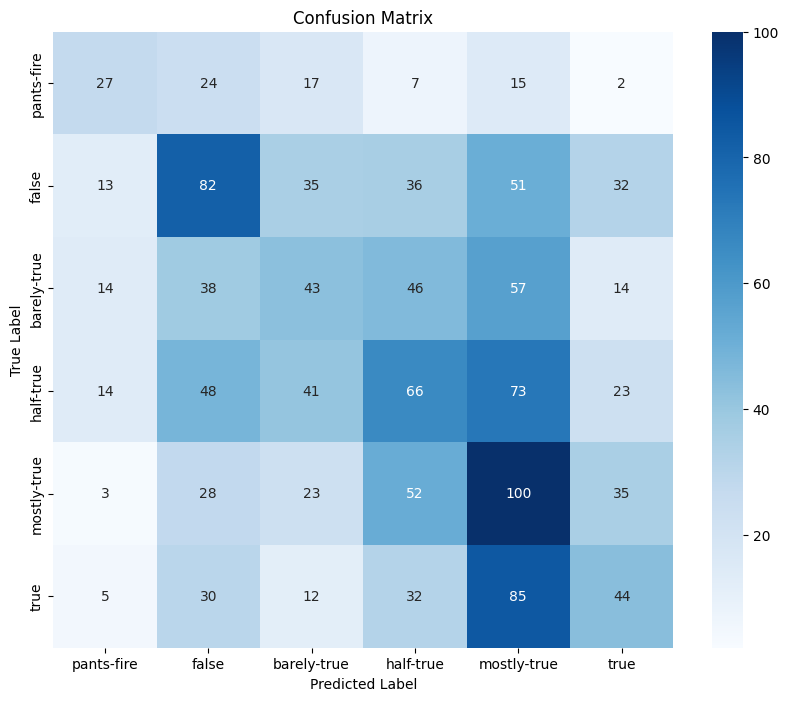

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use the trainer.predict() method on the test_dataset
# The Trainer expects a Hugging Face Dataset or a PyTorch Dataset that returns dicts
# Since test_dataset is a TensorDataset, we need to ensure the data_collator handles it correctly for prediction.
# Our collate_fn_for_tensor_dataset is suitable for this.

test_predictions = trainer.predict(test_dataset)

# 2. Extract the true labels (y_true) and predicted labels (y_pred)
y_true = test_predictions.label_ids
y_pred = np.argmax(test_predictions.predictions, axis=1)

# 3. Generate and print a classification report
# Invert label_map to get label names for target_names
id_to_label = {v: k for k, v in label_map.items()}
target_names = [id_to_label[i] for i in sorted(id_to_label.keys())]

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# 4. Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 5. Visualize the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
print("\n--- Error Analysis ---\n")

# Find misclassified examples
misclassified_indices = np.where(y_true != y_pred)[0]

print(f"Total misclassified examples: {len(misclassified_indices)} out of {len(y_true)}")

# Display some misclassified examples
num_examples_to_display = 10
print(f"\nDisplaying first {num_examples_to_display} misclassified examples:\n")

for i, idx in enumerate(misclassified_indices):
    if i >= num_examples_to_display:
        break
    statement = test_df.iloc[idx]['statement']
    true_label = id_to_label[y_true[idx]]
    predicted_label = id_to_label[y_pred[idx]]
    print(f"Example {i+1}:")
    print(f"  Statement: {statement}")
    print(f"  True Label: {true_label}")
    print(f"  Predicted Label: {predicted_label}\n")

print("Consider manually reviewing these examples to identify patterns in misclassifications, such as ambiguous statements, specific topics, or subtle linguistic cues.")


--- Error Analysis ---

Total misclassified examples: 905 out of 1267

Displaying first 10 misclassified examples:

Example 1:
  Statement: Building a wall on the U.S.-Mexico border will take literally years.
  True Label: true
  Predicted Label: false

Example 2:
  Statement: Wisconsin is on pace to double the number of layoffs this year.
  True Label: false
  Predicted Label: mostly-true

Example 3:
  Statement: Says John McCain has done nothing to help the vets.
  True Label: false
  Predicted Label: barely-true

Example 4:
  Statement: Suzanne Bonamici supports a plan that will cut choice for Medicare Advantage seniors.
  True Label: half-true
  Predicted Label: barely-true

Example 5:
  Statement: Over the past five years the federal government has paid out $601 million in retirement and disability benefits to deceased former federal employees.
  True Label: true
  Predicted Label: mostly-true

Example 6:
  Statement: Says that Tennessee law requires that schools receive half of 

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights for imbalance
# Use the numerical label_ids from the training set
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.sort(train_df['label_id'].unique()),
    y=train_df['label_id']
)

# Convert to a PyTorch tensor
weights = torch.tensor(class_weights, dtype=torch.float32)

print("Calculated class weights:", weights)

Calculated class weights: tensor([2.0342, 0.8555, 1.0318, 0.8073, 0.8699, 1.0183])



--- Classification Report for Retrained Model (with weighted loss) ---
              precision    recall  f1-score   support

  pants-fire       0.25      0.38      0.30        92
       false       0.38      0.18      0.24       249
 barely-true       0.24      0.25      0.25       212
   half-true       0.28      0.20      0.23       265
 mostly-true       0.26      0.22      0.24       241
        true       0.24      0.46      0.32       208

    accuracy                           0.26      1267
   macro avg       0.27      0.28      0.26      1267
weighted avg       0.28      0.26      0.26      1267



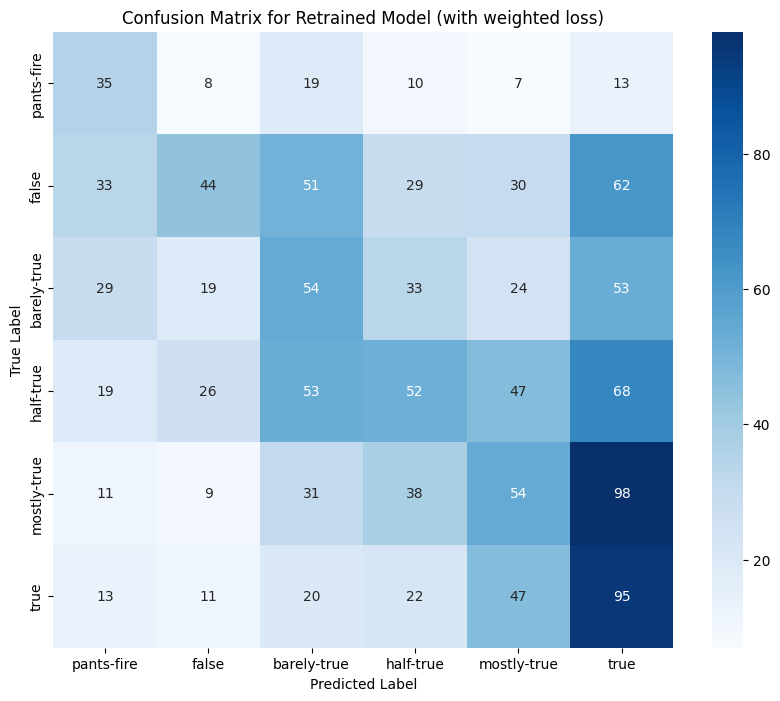


Evaluation of the retrained model complete. Compare these results with the previous evaluation to assess improvement.


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use the trainer.predict() method on the test_dataset to obtain predictions from the retrained model.
test_predictions_retrained = trainer.predict(test_dataset)

# 2. Extract the true labels (y_true) and predicted labels (y_pred)
y_true_retrained = test_predictions_retrained.label_ids
y_pred_retrained = np.argmax(test_predictions_retrained.predictions, axis=1)

# Invert label_map to get label names for target_names (already available from previous execution)
id_to_label = {v: k for k, v in label_map.items()}
target_names = [id_to_label[i] for i in sorted(id_to_label.keys())]

# 3. Generate and print a classification report
print("\n--- Classification Report for Retrained Model (with weighted loss) ---")
print(classification_report(y_true_retrained, y_pred_retrained, target_names=target_names))

# 4. Compute the confusion matrix
cm_retrained = confusion_matrix(y_true_retrained, y_pred_retrained)

# 5. Visualize the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_retrained, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Retrained Model (with weighted loss)')
plt.show()

print("\nEvaluation of the retrained model complete. Compare these results with the previous evaluation to assess improvement.")

In [ ]:
print("\n--- Error Analysis for Retrained Model (with weighted loss) ---\n")

# 1. Identify the indices where the true labels (y_true_retrained) do not match the predicted labels (y_pred_retrained)
misclassified_indices_retrained = np.where(y_true_retrained != y_pred_retrained)[0]

# 2. Print the total number of misclassified examples
print(f"Total misclassified examples (retrained model): {len(misclassified_indices_retrained)} out of {len(y_true_retrained)}")

# 3. Display a selection of these misclassified examples
num_examples_to_display = 10
print(f"\nDisplaying first {num_examples_to_display} misclassified examples from the retrained model:\n")

for i, idx in enumerate(misclassified_indices_retrained):
    if i >= num_examples_to_display:
        break
    statement = test_df.iloc[idx]['statement']
    true_label = id_to_label[y_true_retrained[idx]]
    predicted_label = id_to_label[y_pred_retrained[idx]]
    print(f"Example {i+1}:")
    print(f"  Statement: {statement}")
    print(f"  True Label: {true_label}")
    print(f"  Predicted Label: {predicted_label}\n")

# 4. Add a concluding print statement
print("Consider manually reviewing these examples to identify patterns in misclassifications, and compare with the initial model's errors to assess the impact of weighted loss. Look for cases where previously misclassified examples are now correct, or if new types of errors have emerged.")


--- Error Analysis for Retrained Model (with weighted loss) ---

Total misclassified examples (retrained model): 933 out of 1267

Displaying first 10 misclassified examples from the retrained model:

Example 1:
  Statement: Building a wall on the U.S.-Mexico border will take literally years.
  True Label: true
  Predicted Label: false

Example 2:
  Statement: Wisconsin is on pace to double the number of layoffs this year.
  True Label: false
  Predicted Label: half-true

Example 3:
  Statement: Says John McCain has done nothing to help the vets.
  True Label: false
  Predicted Label: barely-true

Example 4:
  Statement: Suzanne Bonamici supports a plan that will cut choice for Medicare Advantage seniors.
  True Label: half-true
  Predicted Label: barely-true

Example 5:
  Statement: When asked by a reporter whether hes at the center of a criminal scheme to violate campaign laws, Gov. Scott Walker nodded yes.
  True Label: pants-fire
  Predicted Label: true

Example 6:
  Statement: Say

In [ ]:
!pip install gradio
print("Gradio library installation initiated.")

Gradio library installation initiated.


In [ ]:
import gradio as gr
import torch.nn.functional as F

# Ensure the model is in evaluation mode and on the correct device
# Assuming 'model' and 'tokenizer' are already defined and loaded from previous steps
# and 'id_to_label' is also available.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

def predict_fake_news(text):
    # 1. Tokenize the input text
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=128)

    # 2. Move tensors to the appropriate device
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    # 3. Pass the tokenized input to the trained model to get logits
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits

    # 4. Apply softmax to the logits to get probabilities
    probabilities = F.softmax(logits, dim=1)

    # 5. Get the predicted label ID by finding the index of the maximum probability
    predicted_label_id = torch.argmax(probabilities, dim=1).item()

    # 6. Map the predicted label ID back to its string representation
    predicted_label = id_to_label[predicted_label_id]

    # Return the predicted label and optionally probabilities for all classes
    # formatted for display
    prob_dict = {id_to_label[i]: round(prob.item(), 4) for i, prob in enumerate(probabilities[0])}

    return f"Predicted Label: {predicted_label}\nProbabilities: {prob_dict}"

# 3. Create a Gradio Interface
iface = gr.Interface(
    fn=predict_fake_news,
    inputs=gr.Textbox(lines=5, label='Enter a news statement'),
    outputs=gr.Textbox(label='Prediction'),
    title='Fake News Detector',
    description='Enter a news statement to classify it into one of the LIAR dataset categories (pants-fire, false, barely-true, half-true, mostly-true, true).',
    examples=[
        ["Says the Annies List political group supports third-trimester abortions on demand."],
        ["When did the decline of coal start? It started when natural gas started to become popular in 2008."],
        ["Building a wall on the U.S.-Mexico border will take literally years."]
    ]
)

# 4. Launch the Gradio interface
print("Launching Gradio interface...")
iface.launch(share=True)

Launching Gradio interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7dc988db878c5f9305.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
